In [25]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
import math
from google.colab.patches import cv2_imshow
from PIL import Image as im

In [4]:
def convolution2d(image, kernel, stride, padding):
    # Ukuran gambar dan kernel
    image_h, image_w = image.shape
    kernel_h, kernel_w = kernel.shape

    # Tambahkan padding pada gambar
    padded_image = np.pad(
        image,
        ((padding, padding), (padding, padding)),
        mode='constant'
    )

    # Menghitung ukuran output
    output_h = ((image_h + 2 * padding - kernel_h) // stride) + 1
    output_w = ((image_w + 2 * padding - kernel_w) // stride) + 1

    # Membuat matriks output
    output = np.zeros((output_h, output_w))

    # Membalik kernel untuk proses konvolusi
    kernel = np.flipud(np.fliplr(kernel))

    # Proses konvolusi
    for y in range(output_h):
        for x in range(output_w):
            # Menentukan posisi awal
            y_start = y * stride
            x_start = x * stride

            # Mengambil bagian gambar sesuai ukuran kernel
            region = padded_image[
                y_start:y_start + kernel_h,
                x_start:x_start + kernel_w
            ]

            # Perkalian elemen lalu dijumlahkan
            output[y, x] = np.sum(region * kernel)

    return output


In [5]:
img = cv.imread('/content/drive/MyDrive/PCVK/mandrill.tiff')
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

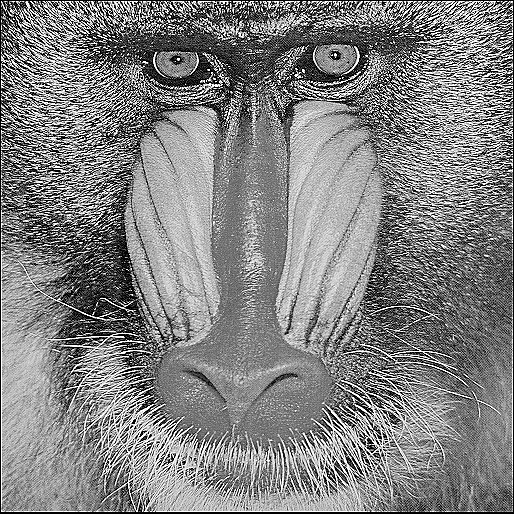

In [6]:
# image sharpening
kernel_sharpen = np.array([[0,-1,0], [-1,5,-1], [0,-1,0]])

cv2_imshow(convolution2d(img_gray, kernel_sharpen, 1, 2))

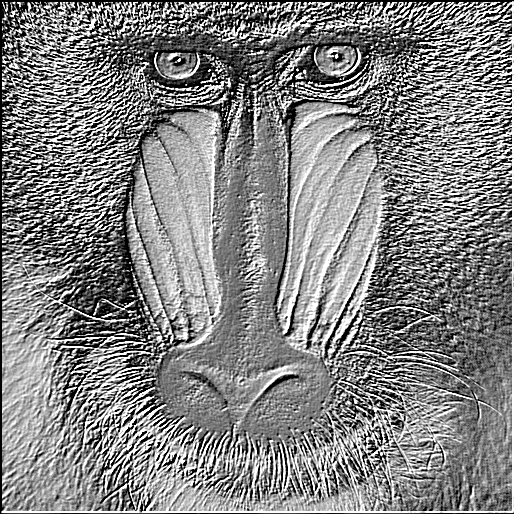

In [7]:
# image emboss
kernel_emboss = np.array([[-2,-1,0], [-1,1,1], [0,1,2]])

cv2_imshow(convolution2d(img_gray, kernel_emboss, 1, 2))

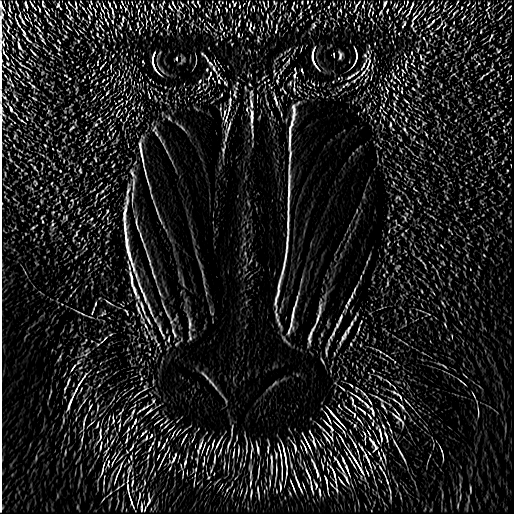

In [8]:
# image left sobel edge detection
kernel_left_sobel_edge_detection = np.array([[1,0,-1], [2,0,-2], [1,0,-1]])

cv2_imshow(convolution2d(img_gray, kernel_left_sobel_edge_detection, 1, 2))

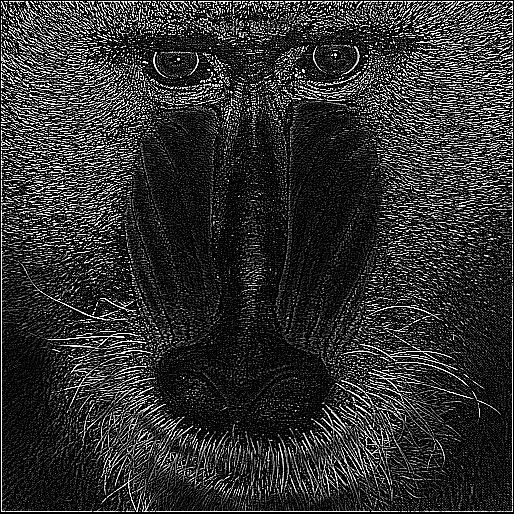

In [9]:
# image canny edge detection
kernel_canny_edge_detection = np.array([[-1,-1,-1], [-1,8,-1], [-1,-1,-1]])

cv2_imshow(convolution2d(img_gray, kernel_canny_edge_detection, 1, 2))

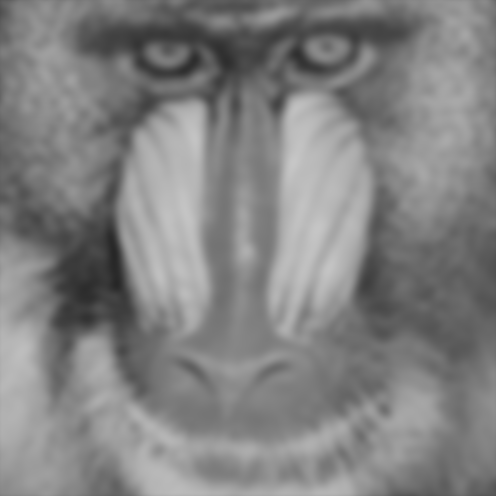

In [10]:
# image 21 x 21 gaussian blur

kernel_size = 21

sigma=math.sqrt(kernel_size)
gaussian_kernel = cv.getGaussianKernel(kernel_size, sigma)
gauss_kernel = gaussian_kernel @ gaussian_kernel.transpose()

cv2_imshow(convolution2d(img_gray, gauss_kernel, 1, 2))

In [11]:
# fungsi side by side

def show_side_by_side(images, titles, figsize=(15, 5)):
    plt.figure(figsize=figsize)
    for i, (img, title) in enumerate(zip(images, titles)):
        if len(img.shape) == 2: # gray
            plt.subplot(1, len(images), i+1)
            plt.imshow(img, cmap="gray")
        else:
            plt.subplot(1,  len(images), i+1)
            plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
        plt.title(title)
        plt.axis("off")
    plt.show()


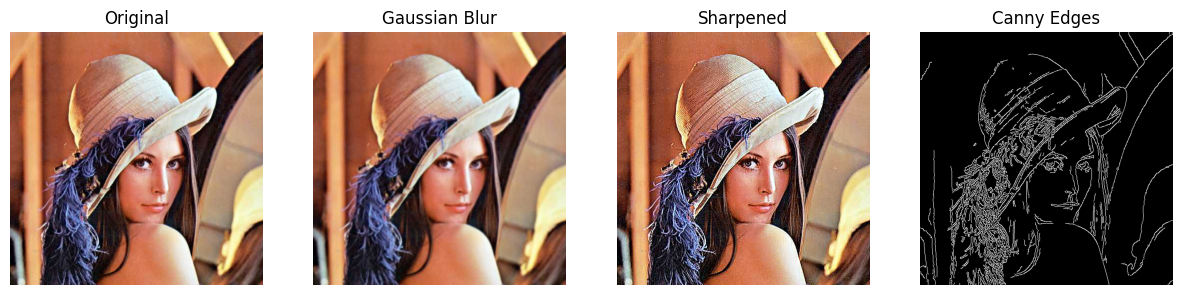

In [12]:
img = cv.imread('/content/drive/MyDrive/PCVK/lena.jpg')
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

blur = cv.GaussianBlur(img, (7, 7), 1)
edges = cv.Canny(cv.cvtColor(img, cv.COLOR_BGR2GRAY), 100, 200)
sharpen_kernel = np.array([[0,-1,0], [-1,5,-1], [0,-1,0]])
sharpened = cv.filter2D(img, -1, sharpen_kernel)
show_side_by_side([img, blur, sharpened, edges], ["Original", "Gaussian Blur", "Sharpened", "Canny Edges"])

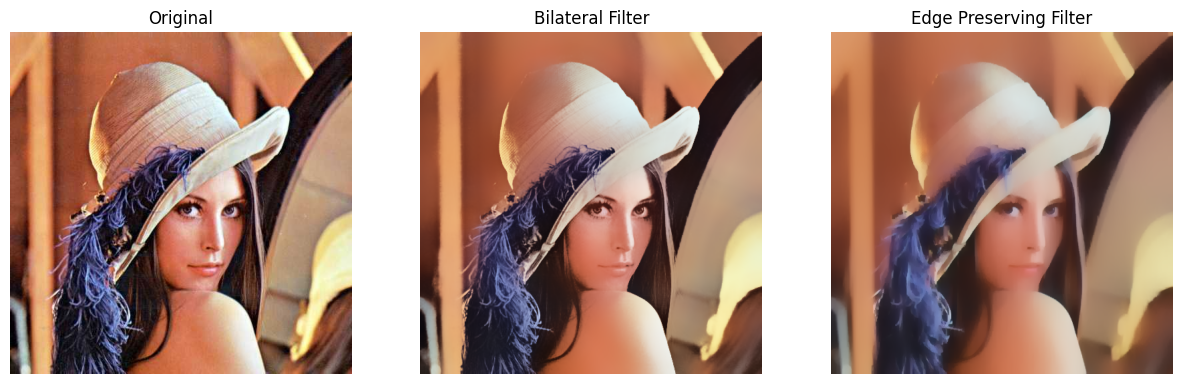

In [13]:
# filter modern dari OpenCV

# bilateral filter (edge-preserving filter)
bilateral = cv.bilateralFilter(img, 50, 100, 100)

# edge preserving filter (edge-preserving filter)
edge_preserve = cv.edgePreservingFilter(img, flags=1, sigma_s=100, sigma_r=0.9)

show_side_by_side([img, bilateral, edge_preserve], ["Original", "Bilateral Filter", "Edge Preserving Filter"])



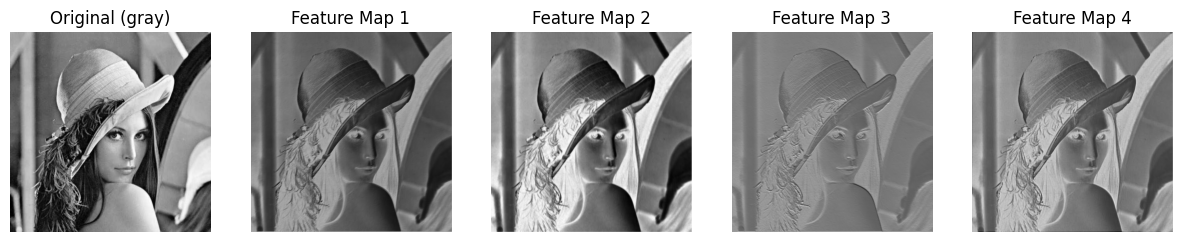

In [14]:
# filter feature map yang digunakan pada CNN, lakukan running code ini beberapa kali
import torch
import torch.nn as nn

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self,).__init__()
        self.conv1 = nn.Conv2d(1, 4, kernel_size=3, stride=1, padding=1)
    
    def forward(self, x):
        return self.conv1(x)

model = SimpleCNN()

# ubah gambar ke tensor
img_tensor = torch.tensor(img_gray, dtype=torch.float32).unsqueeze(0).unsqueeze(0) / 255.0

# hasil CNN
with torch.no_grad():
    features = model(img_tensor)

# visualisasi feature map
feature_map = [features[0,i].numpy() for i in range(features.shape[1])]
show_side_by_side([img_gray] + feature_map, ["Original (gray)"] + [f"Feature Map {i+1}" for i in range(len(feature_map))])

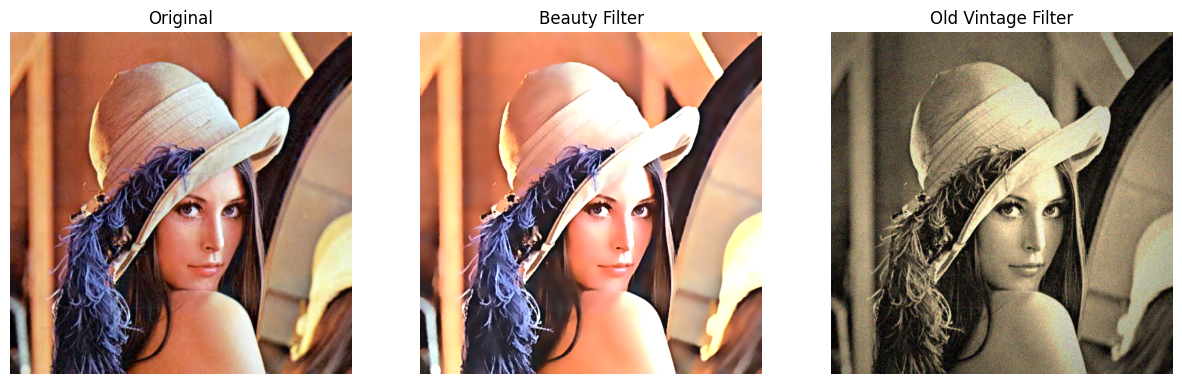

In [15]:
# beauty filter

# step 1
smooth = cv.bilateralFilter(img, d=15, sigmaColor=75, sigmaSpace=75)

# step 2
gaussian = cv.GaussianBlur(smooth, (0, 0), 3)
sharpened = cv.addWeighted(smooth, 1.5, gaussian, -0.5, 0)

# step 3
alpha = 1.2
beta = 15
beauty = cv.convertScaleAbs(sharpened, alpha=alpha, beta=beta)

# old vintage filter

# step 1 sepia tone
sepia_kernel = np.array([[0.272, 0.534, 0.131],
                         [0.349, 0.686, 0.168],
                         [0.393, 0.769, 0.189]])
sepia = cv.transform(img, sepia_kernel)
sepia = np.clip(sepia, 0, 255).astype(np.uint8)

# step 2 vignette effect
rows, cols = img.shape[:2]
kernel_x = cv.getGaussianKernel(cols, cols*0.6)
kernel_y = cv.getGaussianKernel(rows, rows*0.6)
kernel = kernel_y * kernel_x.T
mask = kernel / kernel.max()
vignette = np.copy(sepia)
for i in range(3):
    vignette[:,:,i] = vignette[:,:,i] * mask

# step 3 notes grain
noise = np.random.normal(0, 15, vignette.shape).astype(np.int16)
old_img = np.clip(vignette.astype(np.int16) + noise, 0, 255).astype(np.uint8)

show_side_by_side([img, beauty, old_img], ["Original", "Beauty Filter", "Old Vintage Filter"])

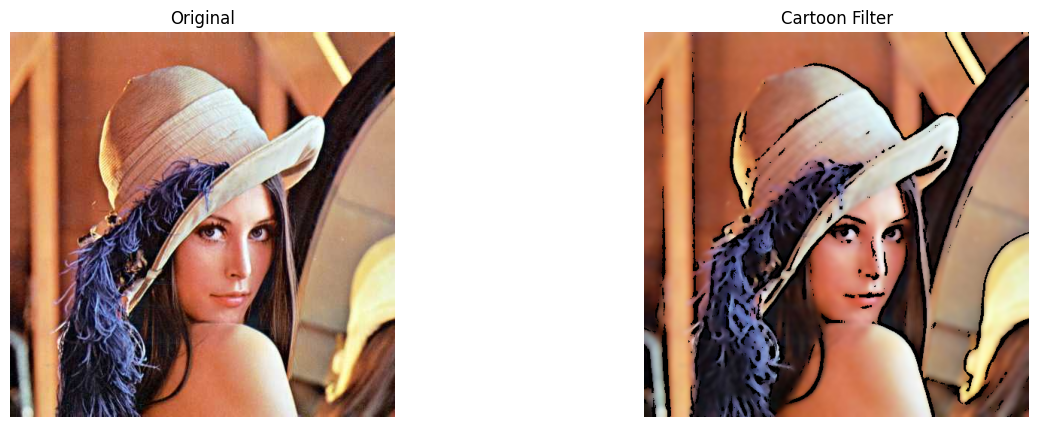

In [16]:
# filter anime atau cartoon
# step 1 edge detection
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
gray_blur = cv.medianBlur(gray, 7)
edges = cv.adaptiveThreshold(gray_blur, 255, cv.ADAPTIVE_THRESH_MEAN_C, cv.THRESH_BINARY, 9, 9)

# step 2 bilateral filter untuk smoothing warna
color = cv.bilateralFilter(img, d=9, sigmaColor=200, sigmaSpace=200)

# step 3 gabungkan
cartoon = cv.bitwise_and(color, color, mask=edges)

# tampilan
show_side_by_side([img, cartoon], ["Original", "Cartoon Filter"])

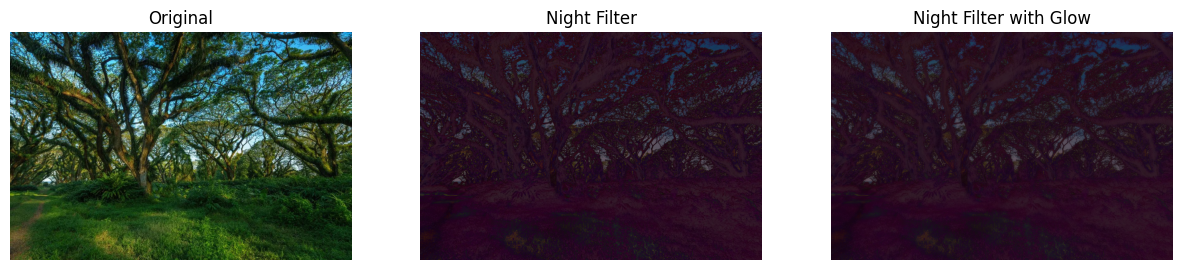

In [17]:
# night filter
img =  cv.imread('/content/drive/MyDrive/PCVK/djawatan.jpg')
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# step 1 gekapkan (kontras turun, brightness naik)
night = cv.convertScaleAbs(img, alpha=0.6, beta=-40)

# step 2 tambah bias biru
blue_tint = np.full_like(night, (50, 0, 100))  # Create a blue tint
night = cv.addWeighted(night, 0.8, blue_tint, 0.2, 0)

# step 3 efek glow di area terang dengan filter=20 (blur kernel)
kernel = np.ones((15,15), np.float32) / 225
glow = cv.filter2D(night, -1, kernel)

# kombinasikan glow dengan gambar asli
night_glow = cv.addWeighted(night, 0.7, glow, 0.3, 0)

show_side_by_side([img, night, night_glow], ["Original", "Night Filter", "Night Filter with Glow"])



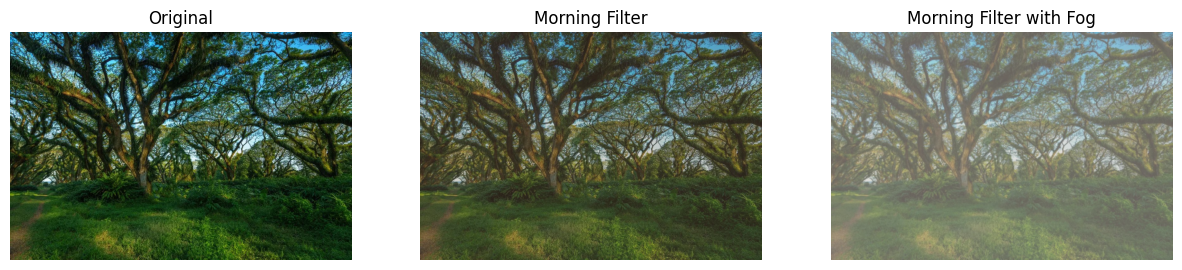

In [18]:
# filter suasana pagi dan kabut

# step 1 kurangi kontras dan cerahkan
alpha = 0.9
beta = 20
soft = cv.convertScaleAbs(img, alpha=alpha, beta=beta)

# step 2 tambahkan warm tone
warm_tint = np.full_like(soft, (40, 70, 120))  # Create a warm tint
pagi = cv.addWeighted(soft, 0.8, warm_tint, 0.2, 0)

# tambahkan haze (kabut tipis) dengan filter2D
# kernel blur gaussian like untuk menciptakan efek kabut
kernel = cv.getGaussianKernel(3, 3)
kernel = kernel @ kernel.T # jadikan kernel 2D
kabut = cv.filter2D(pagi, -1, kernel)

# tambahkan layer putih untuk kabut lebih nyata
white_layer = np.full_like(kabut, 255)
kabut = cv.addWeighted(kabut, 0.7, white_layer, 0.3, 0)

show_side_by_side([img, pagi, kabut], ["Original", "Morning Filter", "Morning Filter with Fog"])

TUGAS PRAKTIKUM

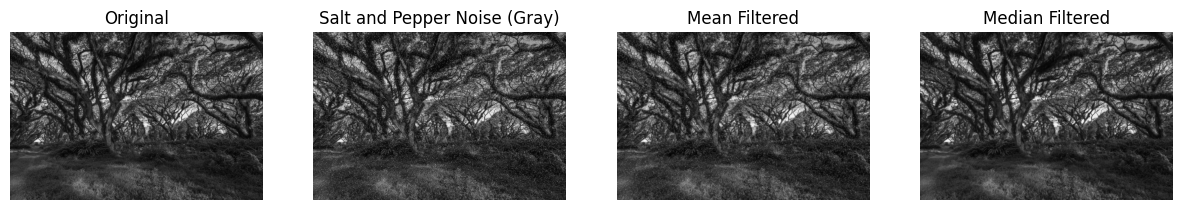

In [19]:
# NOMOR 1

# menambahkan noise bintik bintik salt and pepper
img = cv.imread('/content/drive/MyDrive/PCVK/djawatan.jpg')
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# membuat duplikasi gambar dan probabilitas untuk noise
noisy_img = np.copy(img_gray)
prob = 0.05  # probability of noise

# membuat noise salt and pepper
random_noise = np.random.rand(img.shape[0], img.shape[1])

noisy_img[random_noise < prob / 2] = 255  # salt
noisy_img[random_noise > 1 - prob / 2] = 0  # pepper

# mean filter
mean_filtered_img = cv.blur(noisy_img, (3, 3))

# median filter
median_filtered_img = cv.medianBlur(noisy_img, 3)

# tampilkan hasil
show_side_by_side([img_gray, noisy_img, mean_filtered_img, median_filtered_img], ["Original", "Salt and Pepper Noise (Gray)", "Mean Filtered", "Median Filtered"])

Kenapa median filter lebih bersih dibanding mean filter?

salt and pepper noise biasanya berisik bintik bintik hitam dan putih (0 dan 255)

sehingga pada filter mean akan menghitung nilai rata rata  dari pixel tetangganya (termasuk noisenya juga) sehingga hasilnya akan semakin blur
sedangkan median filter mengabaikan nilai ekstrem dari noise tersebut karna akan diambil nilai tengahnya, sehingga hasilnya tidak terlalu blur

Original:


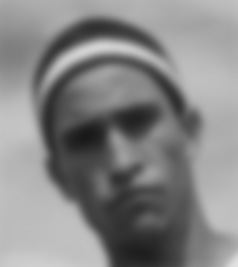

3x3 Sharpening:


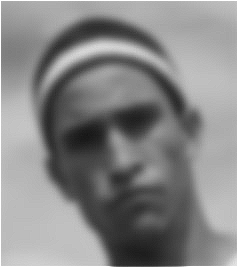

5x5 Sharpening:


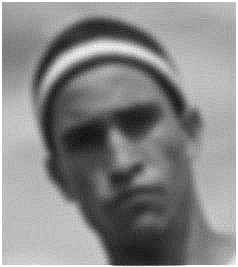

3x3 Sharpening
MSE : 95.92282755798949
PSNR: 28.31158388705257
SSIM: 0.9658774358537283

5x5 Sharpening
MSE : 285.4647027350266
PSNR: 23.575279448012584
SSIM: 0.7976996709157886



In [20]:
# NOMOR 2 TUGAS EVALUASI

import numpy as np
from skimage.metrics import mean_squared_error, peak_signal_noise_ratio
from skimage.metrics import structural_similarity


# load blurry image

img_blur_path = "/content/drive/MyDrive/PCVK/BlurryDavid.jpg"
img_blur = cv.imread(img_blur_path)
img_blur_gray = cv.cvtColor(img_blur, cv.COLOR_BGR2GRAY)

# make 3x3 sharpening kernel
sharpening_kernel_3 = np.array([[0,-1,0], [-1,5,-1], [0,-1,0]])

#make 5x5 sharpening kernel
sharpening_kernel_5 = np.array([
    [ 0,  0, -1,  0,  0],
    [ 0, -1, -1, -1,  0],
    [-1, -1, 13, -1, -1],
    [ 0, -1, -1, -1,  0],
    [ 0,  0, -1,  0,  0]
])

img_sharpen_3 = convolution2d(img_blur_gray, sharpening_kernel_3, 1, 1)
img_sharpen_5 = convolution2d(img_blur_gray, sharpening_kernel_5, 1, 2)

# display image (using convolution2d function from the practicum before)

# original 
print("Original:")
cv2_imshow(img_blur_gray)

# the result of 3x3 sharpening kernel
print("3x3 Sharpening:")
cv2_imshow(img_sharpen_3)

# the result of 5x5 sharpening kernel
print("5x5 Sharpening:")
cv2_imshow(img_sharpen_5)




# Evaluate the noise distortion
# Original clean grayscale image
original = np.clip(img_blur_gray, 0, 255).astype(np.uint8)

# Sharpening results
sharpen_3 = np.clip(img_sharpen_3, 0, 255).astype(np.uint8)
sharpen_5 = np.clip(img_sharpen_5, 0, 255).astype(np.uint8)

# List of images
images = [sharpen_3, sharpen_5]
titles = ["3x3 Sharpening", "5x5 Sharpening"]

# Evaluate each result
for i in range(2):
    mse = mean_squared_error(original, images[i])
    psnr = peak_signal_noise_ratio(original, images[i], data_range=255)
    ssim = structural_similarity(original, images[i], data_range=255)

    print(titles[i])
    print("MSE :", mse)
    print("PSNR:", psnr)
    print("SSIM:", ssim)
    print()




Dari hasil evaluasi dapat disimpulkan bahhwa 3x3 sharpening kernel memproduksi gambar yang lebih mirip dengan gambar aslinya (lebih baik), sednagkan 5x5 sharpening mengubah gambar secara signifikan. Sehingga kernel yang lebih baik untuk sehari hari adalah sharpening kernel 3x3

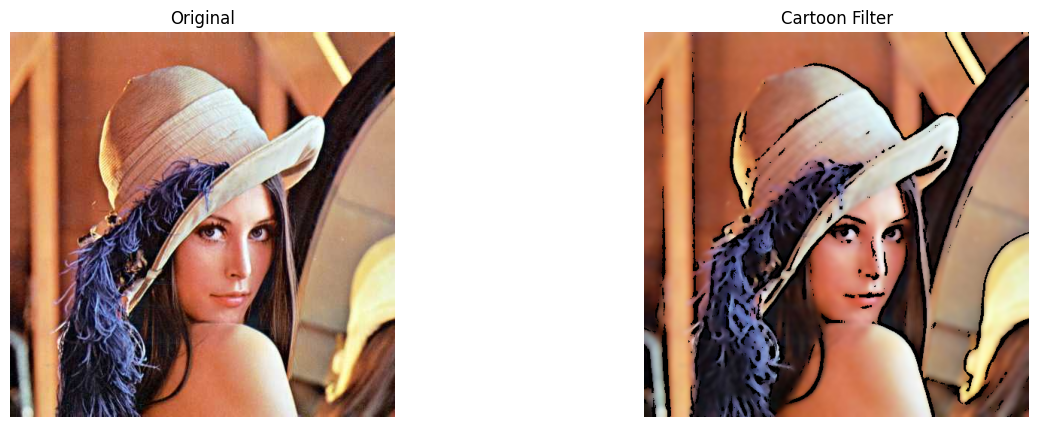

In [26]:
# NOMOR 3

# TUGAS KREASI - FILTER KARTUN SEDERHANA

img = cv.imread('/content/drive/MyDrive/PCVK/lena.jpg')

def kartun(image):
    # Step 1: Deteksi garis tepi
    gray = cv.cvtColor(image, cv.COLOR_BGR2GRAY)
    gray_blur = cv.medianBlur(gray, 7)
    edges = cv.adaptiveThreshold(gray_blur, 255,
                                 cv.ADAPTIVE_THRESH_MEAN_C,
                                 cv.THRESH_BINARY, 9, 9)

    # Step 2: Penghalusan warna menggunakan Bilateral Filter
    color = cv.bilateralFilter(image, d=9, sigmaColor=200, sigmaSpace=200)

    # Step 3: Menggabungkan warna dan garis tepi
    cartoon = cv.bitwise_and(color, color, mask=edges)

    return cartoon


# Memanggil fungsi kartun
hasil_kartun = kartun(img)

# Menampilkan gambar asli dan hasil kartun
show_side_by_side([img, hasil_kartun], ["Original", "Cartoon Filter"])